I will be using this notebook as a Slide Deck for my research.

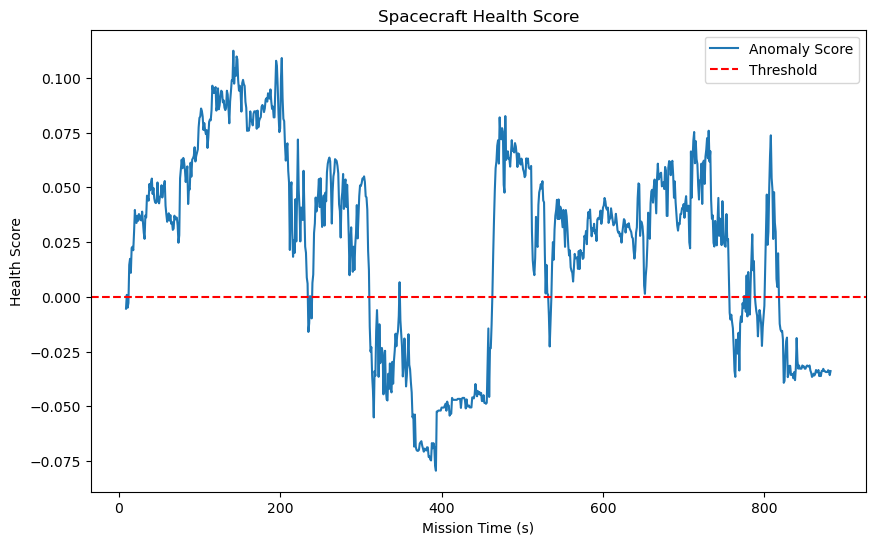

In [2]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

train_df = pd.read_csv("../datasets/clean.csv")
test_df = pd.read_csv("../datasets/o2_leak.csv")

# then select the features
features = ["pitch", "y_pos", "z_pos", "o2_level", "co2_level", "total_drain", "solar_input", "is_scrubber_on", "is_engine_on"]
X_train = train_df[features]

# initialize Isolation Forest model
model = IsolationForest(contamination=0.01, random_state=42)

# train model
model.fit(X_train)

X_test = test_df[features]
test_df['scores'] = model.decision_function(X_test)
test_df['anomaly_pred'] = model.predict(X_test)

# visualize results
plt.figure(figsize=(10,6))
plt.plot(test_df['timestamp'], test_df['scores'], label='Anomaly Score')
plt.axhline(y=0, color='r', linestyle='--', label='Threshold')
plt.title("Spacecraft Health Score")
plt.xlabel("Mission Time (s)")
plt.ylabel("Health Score")
plt.legend()
plt.show()

In [21]:
pd.set_option('display.max_rows', 300)
print(test_df[test_df['scores'] < 0][['timestamp', 'o2_level', 'scores', 'anomaly_pred']])

     timestamp  o2_level    scores  anomaly_pred
0            9    99.964 -0.005407            -1
2           11    99.956 -0.004996            -1
3           12    99.952 -0.002827            -1
226        235    99.060 -0.016054            -1
227        236    99.056 -0.012074            -1
229        238    99.048 -0.000473            -1
230        239    99.044 -0.009863            -1
302        311    98.756 -0.013464            -1
303        312    98.752 -0.025020            -1
304        313    98.748 -0.022993            -1
305        314    98.744 -0.036039            -1
306        315    98.740 -0.042843            -1
307        316    98.736 -0.055125            -1
308        317    98.732 -0.033979            -1
309        318    98.728 -0.036118            -1
310        319    98.724 -0.015536            -1
311        320    98.720 -0.006083            -1
312        321    98.716 -0.016613            -1
313        322    98.712 -0.036560            -1
314        323    98

In [9]:
fp_rows = test_df[(test_df['is_anomaly'] == 0) & (test_df['anomaly_pred'] == -1)]
fp_count = len(fp_rows)

healthy_rows = len(test_df[test_df['is_anomaly'] == 0])

if healthy_rows > 0:
    print(fp_count / healthy_rows)

0.29523809523809524


Working with separate features list for better understanding of data

In [22]:
agents = {
    "ECLSS": ["o2_level", "co2_level", "is_scrubber_on"],
    "EPS": ["total_drain", "solar_input", "is_engine_on", "is_scrubber_on"],
    "GNC": ["pitch", "y_pos", "z_pos"]
}

for name, cols in agents.items():
    model = IsolationForest(contamination=0.01, random_state=42)
    model.fit(train_df[cols])

    test_df[f"{name}_score"] = model.decision_function(test_df[cols])

Adding a Standard Scaler so the model can see data as distance from mean instead of raw numbers (5000W, 20% o2 level, 2 pitch degrees)

In [23]:
from sklearn.preprocessing import StandardScaler
import numpy as np
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_df[agents['ECLSS']])
eclss_model = IsolationForest(contamination=0.01, random_state=42)
eclss_model.fit(X_train_scaled)

mask = test_df['timestamp'] > 100
X_test_scaled = scaler.transform(test_df.loc[mask, agents['ECLSS']])

test_df['eclss_score'] = np.nan
test_df['eclss_pred'] = np.nan

test_df.loc[mask, 'eclss_score'] = eclss_model.decision_function(X_test_scaled)
test_df.loc[mask, 'eclss_pred'] = eclss_model.predict(X_test_scaled)

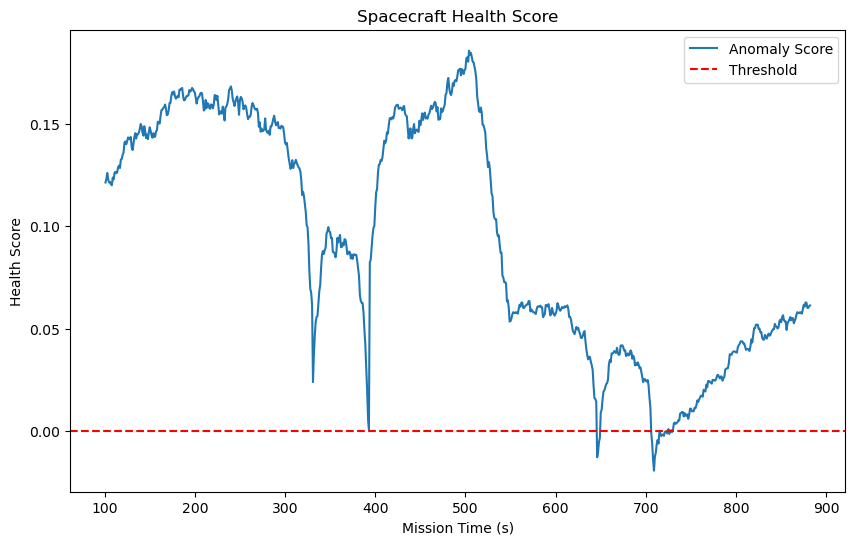

In [24]:
plt.figure(figsize=(10,6))
plt.plot(test_df['timestamp'], test_df['eclss_score'], label='Anomaly Score')
plt.axhline(y=0, color='r', linestyle='--', label='Threshold')
plt.title("Spacecraft Health Score")
plt.xlabel("Mission Time (s)")
plt.ylabel("Health Score")
plt.legend()
plt.show()

In [26]:
valid_mask = test_df['timestamp'] > 100
normal_mask = (test_df["is_anomaly"] == 0) & valid_mask

fp_rate = ((test_df.loc[normal_mask, "eclss_pred"] == -1).mean())

print("FP rate:", fp_rate)
print(
    test_df.loc[valid_mask & (test_df["eclss_pred"] == -1),
                ["timestamp", "o2_level", "co2_level", "eclss_score"]].head(100)
)

FP rate: 0.0
     timestamp  o2_level  co2_level  eclss_score
637        646    93.928      498.0    -0.012609
638        647    93.908      506.0    -0.009932
639        648    93.888      514.0    -0.005245
640        649    93.868      522.0    -0.003129
697        706    92.728      978.0    -0.001104
698        707    92.708      986.0    -0.005954
699        708    92.688      994.0    -0.013909
700        709    92.668      992.0    -0.019168
701        710    92.648      990.0    -0.012243
702        711    92.628      988.0    -0.010458
703        712    92.608      986.0    -0.006390
704        713    92.588      984.0    -0.004168
705        714    92.568      982.0    -0.005936
706        715    92.548      980.0    -0.000524
707        716    92.528      978.0    -0.000820
708        717    92.508      976.0    -0.002230
709        718    92.488      974.0    -0.001646
710        719    92.468      972.0    -0.001555
711        720    92.448      970.0    -0.002177
712    

Testing to see if the model detected the leak before the alarm.

In [28]:
import numpy as np

leak_t = 419
eval_df = test_df[test_df['timestamp'] > 100].copy()

rule_hits = eval_df.loc[eval_df['o2_level'] < 20, 'timestamp']
rule_t = rule_hits.iloc[0] if len(rule_hits) else np.nan

ml_hits = eval_df.loc[(eval_df['timestamp'] >= leak_t) & (eval_df['eclss_pred'] == -1), 'timestamp']
ml_t = ml_hits.iloc[0] if len(ml_hits) else np.nan

print("Leak injected at:", leak_t)
print("Rule alarm (o2<20) at:", rule_t)
print("ML first alarm at:", ml_t)

if np.isnan(rule_t):
    print("Lead time vs rule: N/A (rule never triggered)")
elif not np.isnan(ml_t):
    print("Lead time vs rule (s):", rule_t - ml_t)
    print("Result:", "ML detected EARLIER than rule." if ml_t < rule_t else "ML did NOT detect earlier than rule.")

Leak injected at: 419
Rule alarm (o2<20) at: nan
ML first alarm at: 646
Lead time vs rule: N/A (rule never triggered)
